# ITT Roosevelt - Cali
## Indice de Transformacion Territorial · 5 Dimensiones · 2023-2025
---
**Zona:** Corredor Roosevelt (buffer unico de 100 m)  
**Normalizacion:** `ref_min/ref_max` fijos por indicador  
**Periodo:** 2023-2025

Este notebook replica la estructura metodologica homologada del proyecto, adaptada a la data disponible para Roosevelt.

Supuestos de trabajo:
- La geometria de analisis es un unico buffer del corredor Roosevelt.
- Los eventos ya vienen filtrados a la zona en los archivos fuente.
- Entorno Urbano y Educacion/Desarrollo siguen como referentes provisionales.
- Cohesion Social usa VIF + Rinas + Vulnerabilidad referente.


## Celda 1 Instalacion de dependencias


In [1]:
# Descomentar en Colab
!pip install geopandas pyproj shapely openpyxl matplotlib seaborn folium -q

import subprocess, sys
def check_pkg(pkg):
    try: __import__(pkg)
    except ImportError: subprocess.check_call([sys.executable,'-m','pip','install',pkg,'-q'])
for p in ['geopandas','pyproj','shapely','openpyxl','seaborn','folium']: check_pkg(p)
print('Dependencias verificadas')


Dependencias verificadas


## Celda 2  Importaciones y configuracion


In [2]:
import json, os, warnings
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import folium
warnings.filterwarnings('ignore')

C_SEG='#1B4F8A'; C_MOV='#E8852A'; C_COH='#7B1FA2'; C_ITT='#2E7D32'; BG='#F4F6F9'
NIVEL_COLORS = {'Emergencia':'#E53935','Consolidacion':'#FB8C00','Avance':'#43A047','Transformacion':'#1E88E5'}
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':'white','font.family':'DejaVu Sans',
    'axes.spines.top':False,'axes.spines.right':False,'axes.grid':True,'grid.alpha':0.3})
print('Configuracion visual lista')


Configuracion visual lista


## Celda 3A - Subida ZIP (Colab)


In [3]:
import zipfile
from google.colab import files

print('Selecciona Roosevelt.zip...')
uploaded = files.upload()
for fn, content in uploaded.items():
    with open(f'/content/{fn}','wb') as f:
        f.write(content)
    if fn.lower().endswith('.zip'):
        with zipfile.ZipFile(f'/content/{fn}','r') as z:
            z.extractall('/content/')
        print(f'ZIP extraido: {fn}')


Selecciona Roosevelt.zip...


Saving Roosevelt.zip to Roosevelt.zip
ZIP extraido: Roosevelt.zip


## Celda 3 - Parametros, rutas y umbrales ref_min / ref_max
Los umbrales definen el rango de normalizacion de cada indicador.

Para Roosevelt se proponen refs iniciales de corredor mediano, editables segun validacion tecnica.


In [4]:
import os

BASE = '/content/Roosevelt/Geojson_Roosevelt/'
# BASE = './Roosevelt/Geojson_Roosevelt/'   # local

PATHS = {
    'poligono':    BASE + 'Geojson_tramos_Roosevelt_Buffer_100.geojson',
    'homicidios':  BASE + 'HOMICIDIOS_2023_2025_Roosevelt.geojson',
    'hurtos':      BASE + 'HURTOS_2023_2025_Roosevelt.geojson',
    'siniestros':  BASE + 'BD_SINIESTROS_2023_2025_COMUNA_BARRIO_4326_Roosevelt.geojson',
    'vif':         BASE + 'VIOLENCIA_INTRAFAMILIAR_2023_2025_Roosevelt.geojson',
    'comparendos': BASE + 'COMPARENDOS_2023_2025_Roosevelt.geojson',
    'vbg':         BASE + 'VBG_2025_Roosevelt.geojson',
    'sedes':       BASE + 'Sedes_educativas_oficiales_Roosevelt.geojson',
}

ANIOS = [2023, 2024, 2025]
ZONA_NOMBRE = 'Corredor Roosevelt, Cali'

# ==========================================================
# PESOS por dimension (deben sumar 1.0)
# ==========================================================
PESOS = {
    'Seguridad': 0.30, 'Movilidad': 0.25,
    'EntornoU':  0.20, 'EducDes':   0.13, 'Cohesion':  0.12,
}

# ==========================================================
# REF_MIN y REF_MAX por indicador (juicio experto inicial)
# Ajustados a la escala observada del corredor Roosevelt
# ==========================================================
REFS = {
    #                  ref_min  ref_max  inverso  descripcion
    'homicidios':     (0,       8,       True,    'Homicidios anuales en el corredor'),
    'hurtos':         (120,     320,     True,    'Hurtos anuales en el corredor'),
    'siniestralidad': (15,      40,      True,    'Siniestros viales anuales'),
    'lesionados':     (10,      35,      True,    'Accidentes con lesionados anuales'),
    'mortales':       (0,       4,       True,    'Accidentes mortales anuales'),
    'vif':            (4,       18,      True,    'Violencia intrafamiliar anual'),
    'rinas':          (5,       25,      True,    'Rinas / conflictividad anual'),
}

# ==========================================================
# Scores referentes para dimensiones SIN datos propios
# Fuente: Pulmon de Oriente
# ==========================================================
REF_ENTORNO_U      = 39.2
REF_EDUC_DES       = 54.9
REF_VULNERABILIDAD = 54.1

# Verificar archivos
ok = True
for n, r in PATHS.items():
    e = os.path.exists(r)
    print(f'  {chr(9989) if e else chr(10060)}  {n}')
    if not e: ok = False
print()
print('Periodo:', f'{ANIOS[0]}-{ANIOS[-1]}')
print('Pesos:', ' | '.join(f'{k}={v:.0%}' for k,v in PESOS.items()))
print()
print('Umbrales ref_min / ref_max:')
for ind, (rmin, rmax, inv, desc) in REFS.items():
    print(f'  {ind:18s}  [{rmin:>4} - {rmax:>4}]  inv={inv}  | {desc}')


  ✅  poligono
  ✅  homicidios
  ✅  hurtos
  ✅  siniestros
  ✅  vif
  ✅  comparendos
  ✅  vbg
  ✅  sedes

Periodo: 2023-2025
Pesos: Seguridad=30% | Movilidad=25% | EntornoU=20% | EducDes=13% | Cohesion=12%

Umbrales ref_min / ref_max:
  homicidios          [   0 -    8]  inv=True  | Homicidios anuales en el corredor
  hurtos              [ 120 -  320]  inv=True  | Hurtos anuales en el corredor
  siniestralidad      [  15 -   40]  inv=True  | Siniestros viales anuales
  lesionados          [  10 -   35]  inv=True  | Accidentes con lesionados anuales
  mortales            [   0 -    4]  inv=True  | Accidentes mortales anuales
  vif                 [   4 -   18]  inv=True  | Violencia intrafamiliar anual
  rinas               [   5 -   25]  inv=True  | Rinas / conflictividad anual


## Celda 4 - Carga de datos


In [5]:
def load_gj(path):
    with open(path, encoding='utf-8') as f: return json.load(f)

gdf_roosevelt = gpd.read_file(PATHS['poligono'])
gdf_roosevelt_wgs = gdf_roosevelt.to_crs('EPSG:4326')

raw_hom  = load_gj(PATHS['homicidios'])
raw_hur  = load_gj(PATHS['hurtos'])
raw_sin  = load_gj(PATHS['siniestros'])
raw_vif  = load_gj(PATHS['vif'])
raw_comp = load_gj(PATHS['comparendos'])
raw_vbg  = load_gj(PATHS['vbg'])
raw_sed  = load_gj(PATHS['sedes'])

for n, r in [('Homicidios',raw_hom),('Hurtos',raw_hur),('Siniestros',raw_sin),
             ('VIF',raw_vif),('Comparendos',raw_comp),('VBG',raw_vbg),
             ('Sedes',raw_sed)]:
    print(f'  {n:15s}: {len(r["features"]):>4} registros')


  Homicidios     :    5 registros
  Hurtos         :  730 registros
  Siniestros     :   72 registros
  VIF            :   24 registros
  Comparendos    : 1300 registros
  VBG            :    4 registros
  Sedes          :    2 registros


## Celda 5 - Mapa de geolocalizacion


In [6]:
centroid = gdf_roosevelt_wgs.geometry.centroid.iloc[0]
m = folium.Map(location=[centroid.y, centroid.x], zoom_start=16, tiles='CartoDB positron')

folium.GeoJson(gdf_roosevelt_wgs.__geo_interface__, name='Corredor Roosevelt (buffer 100 m)',
    style_function=lambda x: {'fillColor':'#F9A825','color':'#1B4F8A','weight':2,'fillOpacity':0.10}).add_to(m)

capas = [
    ('Homicidios',  raw_hom, 'FECHA_HECH','X','Y','red','exclamation-sign'),
    ('Hurtos',      raw_hur, 'FECHA_HECH','X','Y','blue','shopping-cart'),
    ('Siniestros',  raw_sin, 'Fecha',None,None,'orange','road'),
    ('VIF',         raw_vif, 'FECHA_HECH','X','Y','purple','home'),
]
for nombre, raw, col_f, cx, cy, color, icon in capas:
    fg = folium.FeatureGroup(name=nombre)
    for feat in raw['features']:
        p = feat['properties']
        if feat.get('geometry') and feat['geometry'].get('coordinates'):
            lon, lat = feat['geometry']['coordinates'][:2]
        elif cx and cx in p:
            lon, lat = p[cx], p[cy]
        else:
            continue
        fecha = str(p.get(col_f,''))[:10]
        folium.Marker([lat,lon], popup=f'<b>{nombre}</b><br>{fecha}',
            icon=folium.Icon(color=color, icon=icon, prefix='glyphicon')).add_to(fg)
    fg.add_to(m)

fg_r = folium.FeatureGroup(name='Rinas')
for feat in raw_comp['features']:
    p = feat['properties']
    if not str(p.get('agrupado','')).startswith('RI'):
        continue
    if p.get('lat') and p.get('lon'):
        folium.Marker([p['lat'],p['lon']], popup=f'Rina<br>{str(p.get("fecha_hech",""))[:10]}',
            icon=folium.Icon(color='pink',icon='flash',prefix='glyphicon')).add_to(fg_r)
fg_r.add_to(m)

fg_vbg = folium.FeatureGroup(name='VBG 2025', show=False)
for feat in raw_vbg['features']:
    p = feat['properties']
    if p.get('LAT') and p.get('LON'):
        folium.Marker([p['LAT'],p['LON']], popup=f'<b>VBG</b><br>{p.get("DELITO","")}',
            icon=folium.Icon(color='darkpurple',icon='user',prefix='glyphicon')).add_to(fg_vbg)
fg_vbg.add_to(m)

fg_s = folium.FeatureGroup(name='Sedes educativas', show=False)
for feat in raw_sed['features']:
    p = feat['properties']
    if p.get('Latitud_D'):
        folium.Marker([p['Latitud_D'],p['Longitud_D']],
            popup=f'<b>{p.get("NombreSede","Sede")}</b>',
            icon=folium.Icon(color='cadetblue',icon='education',prefix='glyphicon')).add_to(fg_s)
fg_s.add_to(m)

folium.LayerControl().add_to(m)
m


## Celda 6 - Procesamiento de indicadores


In [7]:
def procesar(raw, col_fecha, filtro=None, filtro_col=None, startswith=False):
    df = pd.DataFrame([f['properties'] for f in raw['features']])
    if filtro and filtro_col:
        if startswith:
            df = df[df[filtro_col].astype(str).str.startswith(filtro)].copy()
        else:
            df = df[df[filtro_col]==filtro].copy()
    df['_fecha'] = pd.to_datetime(df[col_fecha])
    df['año'] = df['_fecha'].dt.year
    df['trimestre'] = df['_fecha'].dt.quarter
    return df[df['año'].isin(ANIOS)].copy()

def agg_anual(df): return df.groupby('año').size().reindex(ANIOS, fill_value=0)
def agg_trim(df):
    idx = pd.MultiIndex.from_product([ANIOS,[1,2,3,4]], names=['año','trimestre'])
    return df.groupby(['año','trimestre']).size().reindex(idx, fill_value=0)

df_hom = procesar(raw_hom, 'FECHA_HECH')
df_hur = procesar(raw_hur, 'FECHA_HECH')
df_sin = procesar(raw_sin, 'Fecha')
df_les = df_sin[df_sin['Tipo_Confi']=='Lesiones'].copy()
df_mor = df_sin[df_sin['Tipo_Confi']=='Mortal'].copy()
df_vif = procesar(raw_vif, 'FECHA_HECH')
df_rin = procesar(raw_comp, 'fecha_hech', filtro='RI', filtro_col='agrupado', startswith=True)

# Tabla anual
base = pd.DataFrame({'año': ANIOS})
for nombre, df_src in [('homicidios',df_hom),('hurtos',df_hur),('siniestralidad',df_sin),
                        ('lesionados',df_les),('mortales',df_mor),('vif',df_vif),('rinas',df_rin)]:
    base[nombre] = agg_anual(df_src).values

# Tabla trimestral
idx_t = pd.MultiIndex.from_product([ANIOS,[1,2,3,4]], names=['año','trimestre'])
corr_trim = pd.DataFrame(index=idx_t).reset_index()
for nombre, df_src in [('homicidios',df_hom),('hurtos',df_hur),('siniestralidad',df_sin),
                        ('lesionados',df_les),('mortales',df_mor),('vif',df_vif),('rinas',df_rin)]:
    ser = agg_trim(df_src).reset_index()
    ser.columns = ['año','trimestre',nombre]
    corr_trim = corr_trim.merge(ser, on=['año','trimestre'], how='left').fillna({nombre:0})
corr_trim['periodo'] = corr_trim['año'].astype(str) + '-Q' + corr_trim['trimestre'].astype(str)

print('Indicadores anuales:')
print(base.to_string(index=False))
print()
print('Indicadores trimestrales:')
print(corr_trim.to_string(index=False))


Indicadores anuales:
 año  homicidios  hurtos  siniestralidad  lesionados  mortales  vif  rinas
2023           2     245              31          26         1    9     12
2024           1     274              17          15         2    9     12
2025           2     211              24          22         1    6     17

Indicadores trimestrales:
 año  trimestre  homicidios  hurtos  siniestralidad  lesionados  mortales  vif  rinas periodo
2023          1           1      57               9           7         0    3      2 2023-Q1
2023          2           1      68               8           7         0    2      0 2023-Q2
2023          3           0      64               5           4         0    2      6 2023-Q3
2023          4           0      56               9           8         1    2      4 2023-Q4
2024          1           0      61               7           5         2    5      4 2024-Q1
2024          2           1      76               5           5         0    1      0 20

## Celda 7  Normalizacion con ref_min / ref_max e ITT
Usa umbrales fijos definidos en Celda 3 (no min-max relativo de la muestra).


In [8]:
def score_ref(valor, ref_min, ref_max, inverso):
    """Normaliza un valor con umbrales fijos ref_min/ref_max.
    Si inverso=True, menor valor = mejor score."""
    if ref_max == ref_min: return 100.0
    raw = np.clip((valor - ref_min) / (ref_max - ref_min) * 100, 0, 100)
    return 100 - raw if inverso else raw

# Aplicar normalizacion con refs fijos
for ind, (rmin, rmax, inv, desc) in REFS.items():
    base[f'score_{ind}'] = base[ind].apply(lambda v: score_ref(v, rmin, rmax, inv))

# Scores por dimension
base['score_seguridad'] = (base['score_homicidios'] + base['score_hurtos']) / 2
base['score_movilidad'] = (base['score_siniestralidad'] + base['score_lesionados'] + base['score_mortales']) / 3
base['score_cohesion']  = (base['score_vif'] + base['score_rinas'] + REF_VULNERABILIDAD) / 3
base['score_entorno_u'] = REF_ENTORNO_U
base['score_educ_des']  = REF_EDUC_DES

# ITT Global
base['ITT'] = (
    PESOS['Seguridad'] * base['score_seguridad'] +
    PESOS['Movilidad'] * base['score_movilidad'] +
    PESOS['EntornoU']  * base['score_entorno_u'] +
    PESOS['EducDes']   * base['score_educ_des'] +
    PESOS['Cohesion']  * base['score_cohesion']
)

def clasificar(v):
    if v < 40: return 'Emergencia'
    elif v < 60: return 'Consolidacion'
    elif v < 80: return 'Avance'
    else: return 'Transformacion'

base['nivel'] = base['ITT'].apply(clasificar)

print('ITT Roosevelt - Normalizacion con ref_min/ref_max fijos')
print()
print('Scores por indicador:')
print(base[['año'] + [c for c in base.columns if c.startswith('score_') and 'seguridad' not in c and 'movilidad' not in c and 'cohesion' not in c and 'entorno' not in c and 'educ' not in c]].round(1).to_string(index=False))
print()
print('Scores por dimension e ITT:')
print(base[['año','score_seguridad','score_movilidad','score_cohesion','score_entorno_u','score_educ_des','ITT','nivel']].round(1).to_string(index=False))
print()
print('Detalle contribucion al ITT:')
for _, row in base.iterrows():
    año = int(row['año'])
    contribs = {d: row[f'score_{k}']*PESOS[d] for d,k in [('Seguridad','seguridad'),('Movilidad','movilidad'),
        ('EntornoU','entorno_u'),('EducDes','educ_des'),('Cohesion','cohesion')]}
    det = ' + '.join(f'{d}={v:.1f}' for d,v in contribs.items())
    print(f'  {año}: {det} = ITT {row["ITT"]:.1f} ({row["nivel"]})')


ITT Roosevelt - Normalizacion con ref_min/ref_max fijos

Scores por indicador:
 año  score_homicidios  score_hurtos  score_siniestralidad  score_lesionados  score_mortales  score_vif  score_rinas
2023              75.0          37.5                  36.0              36.0            75.0       64.3         65.0
2024              87.5          23.0                  92.0              80.0            50.0       64.3         65.0
2025              75.0          54.5                  64.0              52.0            75.0       85.7         40.0

Scores por dimension e ITT:
 año  score_seguridad  score_movilidad  score_cohesion  score_entorno_u  score_educ_des  ITT         nivel
2023             56.2             49.0            61.1             39.2            54.9 51.4 Consolidacion
2024             55.2             74.0            61.1             39.2            54.9 57.4 Consolidacion
2025             64.8             63.7            59.9             39.2            54.9 57.5 Consolidac

## Celda 8 Cards de metricas clave


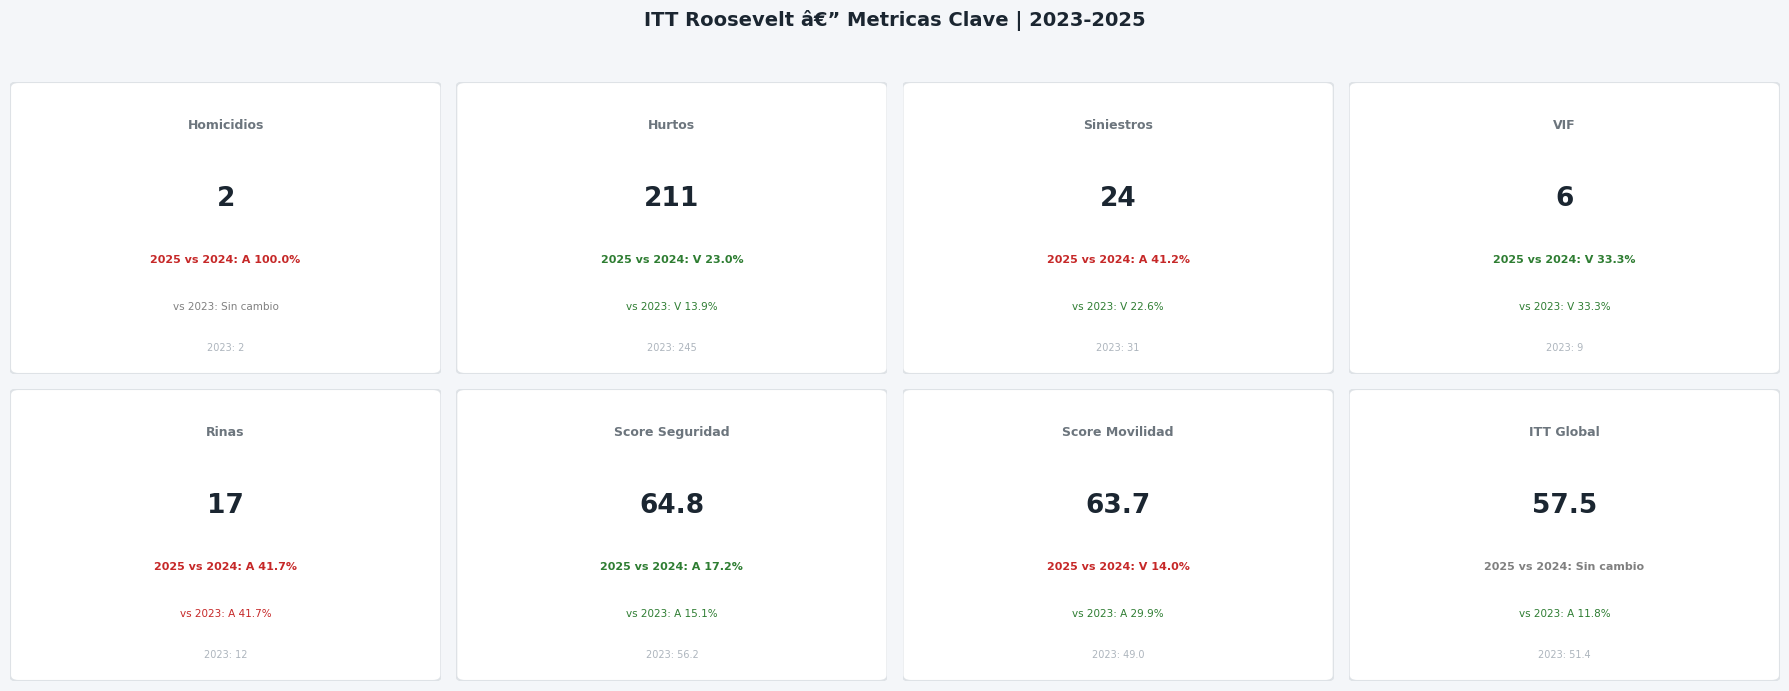

In [15]:
def safe_pct(new, old):
    if old == 0: return 0.0
    return (new - old) / old * 100

def arrow(pct, inv=True):
    if abs(pct) < 1: return 'Sin cambio', 'gray'
    if inv: return (f'V {abs(pct):.1f}%','#2E7D32') if pct<0 else (f'A {abs(pct):.1f}%','#C62828')
    else:  return (f'A {abs(pct):.1f}%','#2E7D32') if pct>0 else (f'V {abs(pct):.1f}%','#C62828')

año_ini, año_ant, año_ult = ANIOS[0], ANIOS[-2], ANIOS[-1]
d_ini = base[base['año']==año_ini].iloc[0]
d_ant = base[base['año']==año_ant].iloc[0]
d_ult = base[base['año']==año_ult].iloc[0]

cards = [
    ('Homicidios',int(d_ini['homicidios']),int(d_ant['homicidios']),int(d_ult['homicidios']),True),
    ('Hurtos',int(d_ini['hurtos']),int(d_ant['hurtos']),int(d_ult['hurtos']),True),
    ('Siniestros',int(d_ini['siniestralidad']),int(d_ant['siniestralidad']),int(d_ult['siniestralidad']),True),
    ('VIF',int(d_ini['vif']),int(d_ant['vif']),int(d_ult['vif']),True),
    ('Rinas',int(d_ini['rinas']),int(d_ant['rinas']),int(d_ult['rinas']),True),
    ('Score Seguridad',d_ini['score_seguridad'],d_ant['score_seguridad'],d_ult['score_seguridad'],False),
    ('Score Movilidad',d_ini['score_movilidad'],d_ant['score_movilidad'],d_ult['score_movilidad'],False),
    ('ITT Global',d_ini['ITT'],d_ant['ITT'],d_ult['ITT'],False),
]

fig, axes = plt.subplots(2, 4, figsize=(18, 7), facecolor=BG)
fig.suptitle(f'ITT Roosevelt â€” Metricas Clave | {año_ini}-{año_ult}',
             fontsize=14, fontweight='bold', color='#1B2631', y=0.98)
for i, (titulo, v_ini, v_ant, v_ult, inv) in enumerate(cards):
    ax = axes[i//4][i%4]; ax.set_xlim(0,1); ax.set_ylim(0,1); ax.axis('off')
    rect = mpatches.FancyBboxPatch((0.02,0.02),0.96,0.96, boxstyle='round,pad=0.02',
        linewidth=1.5, edgecolor='#DEE2E6', facecolor='white')
    ax.add_patch(rect)
    ax.text(0.5,0.85, titulo, ha='center', va='center', fontsize=9, color='#6C757D', fontweight='bold')
    val_d = f'{v_ult:.1f}' if isinstance(v_ult,float) else str(v_ult)
    ax.text(0.5,0.60, val_d, ha='center', va='center', fontsize=19, fontweight='bold', color='#1B2631')
    pct1 = safe_pct(v_ult, v_ant)
    ar1, col1 = arrow(pct1, inv)
    ax.text(0.5,0.38, f'{año_ult} vs {año_ant}: {ar1}', ha='center', fontsize=8, color=col1, fontweight='bold')
    pct2 = safe_pct(v_ult, v_ini)
    ar2, col2 = arrow(pct2, inv)
    ax.text(0.5,0.22, f'vs {año_ini}: {ar2}', ha='center', fontsize=7.5, color=col2)
    ref = f'{v_ini:.1f}' if isinstance(v_ini,float) else str(v_ini)
    ax.text(0.5,0.08, f'{año_ini}: {ref}', ha='center', fontsize=7, color='#ADB5BD')

plt.tight_layout(rect=[0,0,1,0.95])
plt.savefig('itt_roosevelt_cards.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


## Celda 9 Heatmap: Dimension Seguridad


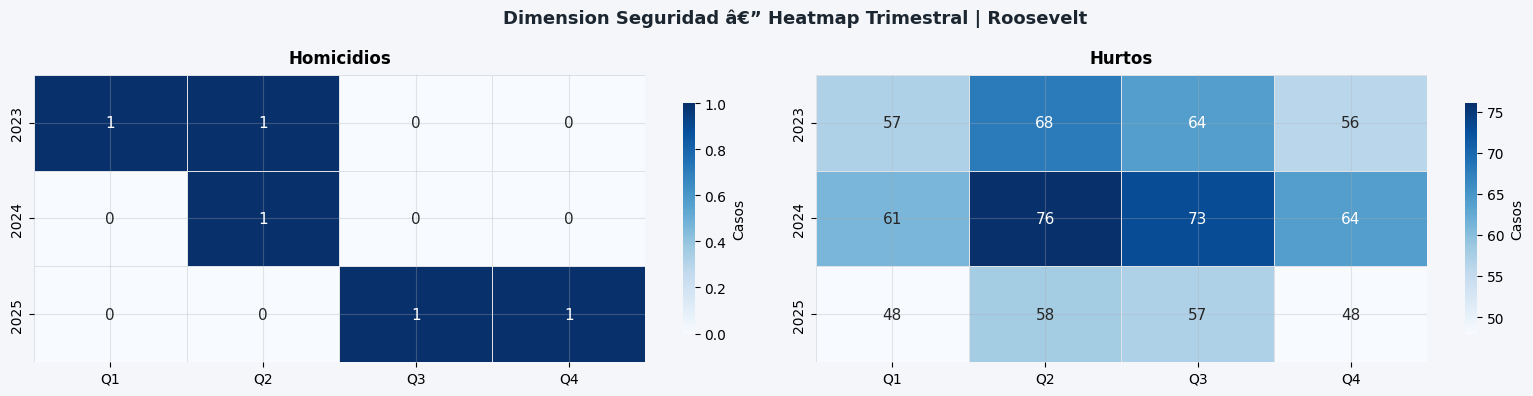

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4), facecolor=BG)
fig.suptitle('Dimension Seguridad â€” Heatmap Trimestral | Roosevelt',
             fontsize=13, fontweight='bold', color='#1B2631')
for ax, col, titulo_h, cmap_h in [
    (axes[0],'homicidios','Homicidios','Blues'),
    (axes[1],'hurtos','Hurtos','Blues')]:
    pivot = corr_trim.pivot(index='año', columns='trimestre', values=col)
    pivot.columns = ['Q1','Q2','Q3','Q4']
    sns.heatmap(pivot, annot=True, fmt='.0f', cmap=cmap_h,
        linewidths=0.5, linecolor='#DEE2E6', ax=ax, annot_kws={'size':11},
        cbar_kws={'label':'Casos','shrink':0.8})
    ax.set_title(titulo_h, fontweight='bold', pad=8)
    ax.set_ylabel(''); ax.set_xlabel('')
plt.tight_layout()
plt.savefig('itt_roosevelt_heatmap_seg.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


## Celda 10 Heatmap: Dimension Movilidad


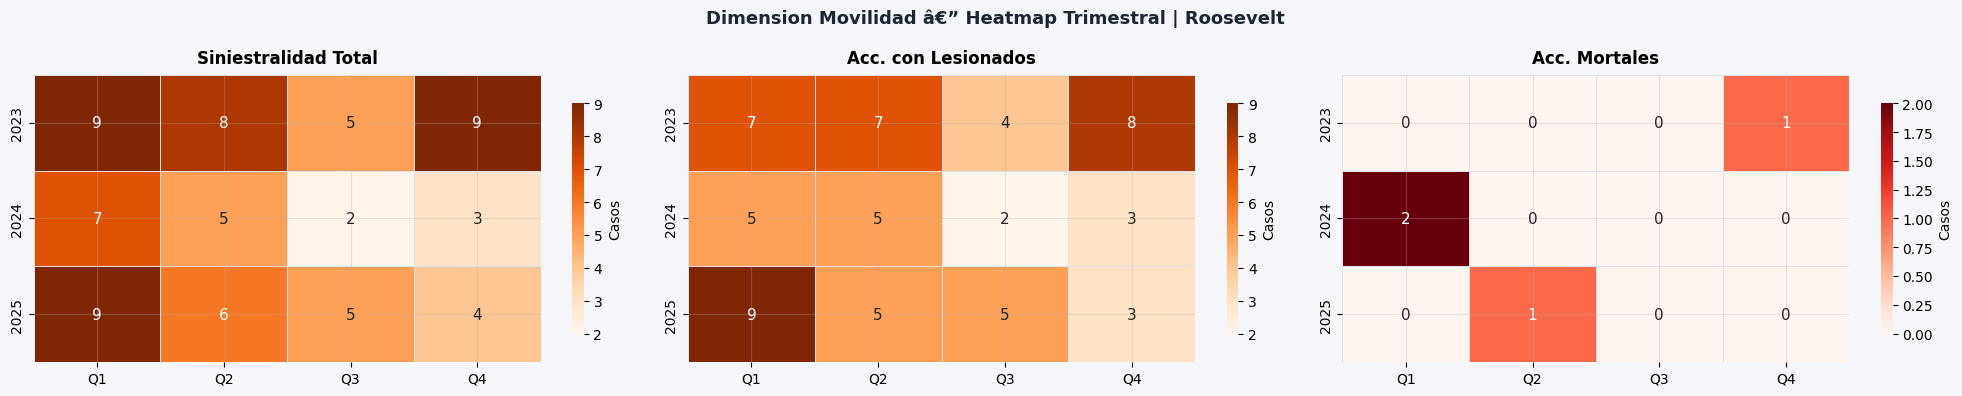

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(20, 4), facecolor=BG)
fig.suptitle('Dimension Movilidad â€” Heatmap Trimestral | Roosevelt',
             fontsize=13, fontweight='bold', color='#1B2631')
for ax, col, titulo_h, cmap_h in [
    (axes[0],'siniestralidad','Siniestralidad Total','Oranges'),
    (axes[1],'lesionados','Acc. con Lesionados','Oranges'),
    (axes[2],'mortales','Acc. Mortales','Reds')]:
    pivot = corr_trim.pivot(index='año', columns='trimestre', values=col)
    pivot.columns = ['Q1','Q2','Q3','Q4']
    sns.heatmap(pivot, annot=True, fmt='.0f', cmap=cmap_h,
        linewidths=0.5, linecolor='#DEE2E6', ax=ax, annot_kws={'size':11},
        cbar_kws={'label':'Casos','shrink':0.8})
    ax.set_title(titulo_h, fontweight='bold', pad=8)
    ax.set_ylabel(''); ax.set_xlabel('')
plt.tight_layout()
plt.savefig('itt_roosevelt_heatmap_mov.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()



## Celda 11 Heatmap: Dimension Cohesion Social


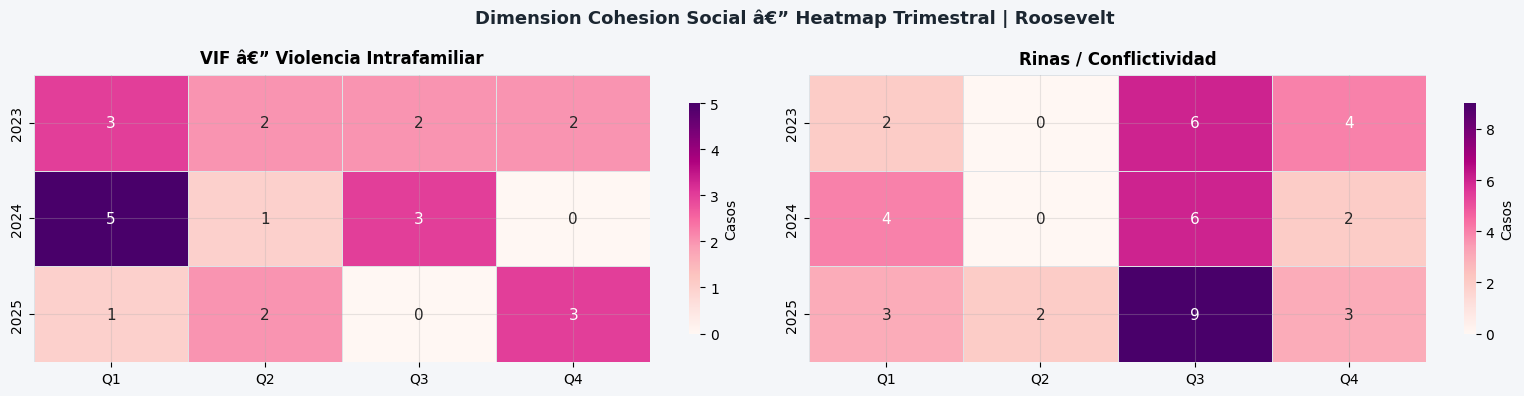

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4), facecolor=BG)
fig.suptitle('Dimension Cohesion Social â€” Heatmap Trimestral | Roosevelt',
             fontsize=13, fontweight='bold', color='#1B2631')
for ax, col, titulo_h in [
    (axes[0],'vif','VIF â€” Violencia Intrafamiliar'),
    (axes[1],'rinas','Rinas / Conflictividad')]:
    pivot = corr_trim.pivot(index='año', columns='trimestre', values=col)
    pivot.columns = ['Q1','Q2','Q3','Q4']
    sns.heatmap(pivot, annot=True, fmt='.0f', cmap='RdPu',
        linewidths=0.5, linecolor='#DEE2E6', ax=ax, annot_kws={'size':11},
        cbar_kws={'label':'Casos','shrink':0.8})
    ax.set_title(titulo_h, fontweight='bold', pad=8)
    ax.set_ylabel(''); ax.set_xlabel('')
plt.tight_layout()
plt.savefig('itt_roosevelt_heatmap_coh.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


## Celda 12 Evolucion trimestral: Seguridad


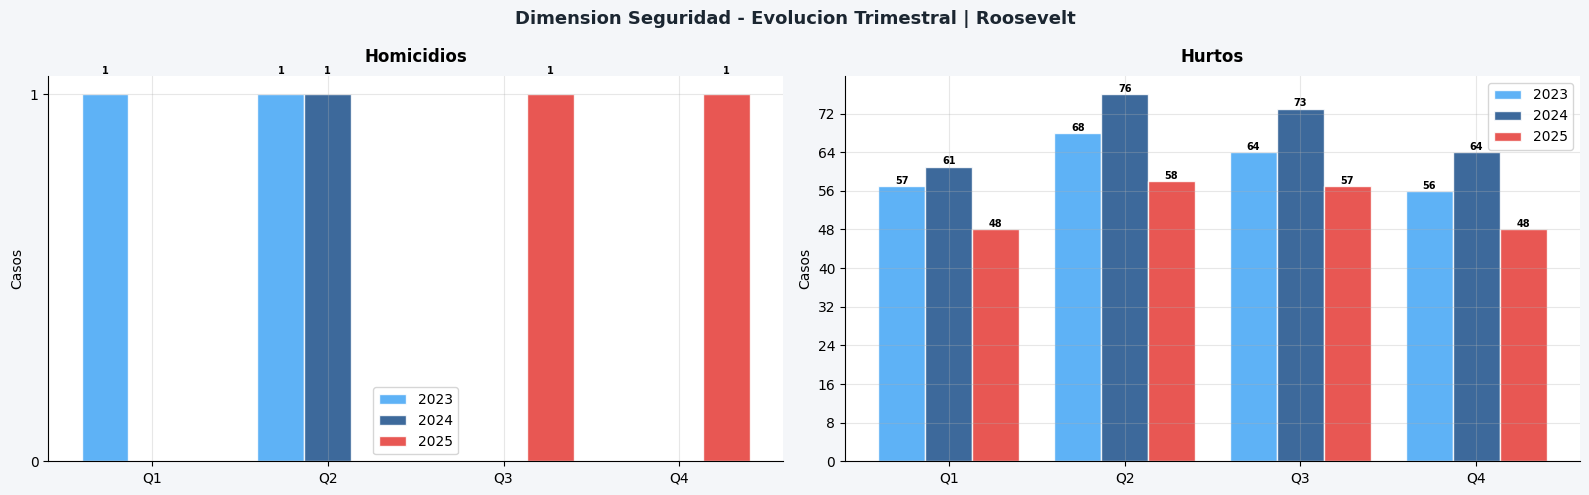

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5), facecolor=BG)
titulo = 'Dimension Seguridad - Evolucion Trimestral | Roosevelt'
fig.suptitle(titulo, fontsize=13, fontweight='bold', color='#1B2631')
x = np.arange(4); n = len(ANIOS); w = 0.8/n
COLORES = ['#42A5F5','#1B4F8A','#E53935']
for ax, col, tp in [(axes[0],'homicidios','Homicidios'),(axes[1],'hurtos','Hurtos')]:
    for idx, año in enumerate(ANIOS):
        vals = corr_trim[corr_trim['año']==año][col].values
        offset = (idx-n/2+0.5)*w
        b = ax.bar(x+offset, vals, w, label=str(año), color=COLORES[idx%3], alpha=0.85, edgecolor='white')
        for bar in b:
            h = bar.get_height()
            if h>0: ax.text(bar.get_x()+bar.get_width()/2, h+0.05, str(int(h)), ha='center', va='bottom', fontsize=7, fontweight='bold')
    ax.set_title(tp, fontweight='bold', pad=10)
    ax.set_xticks(x); ax.set_xticklabels(['Q1','Q2','Q3','Q4'])
    ax.set_ylabel('Casos'); ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True)); ax.legend()
plt.tight_layout()
plt.savefig('itt_roosevelt_seg_trim.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()



## Celda 13 Evolucion trimestral: Movilidad


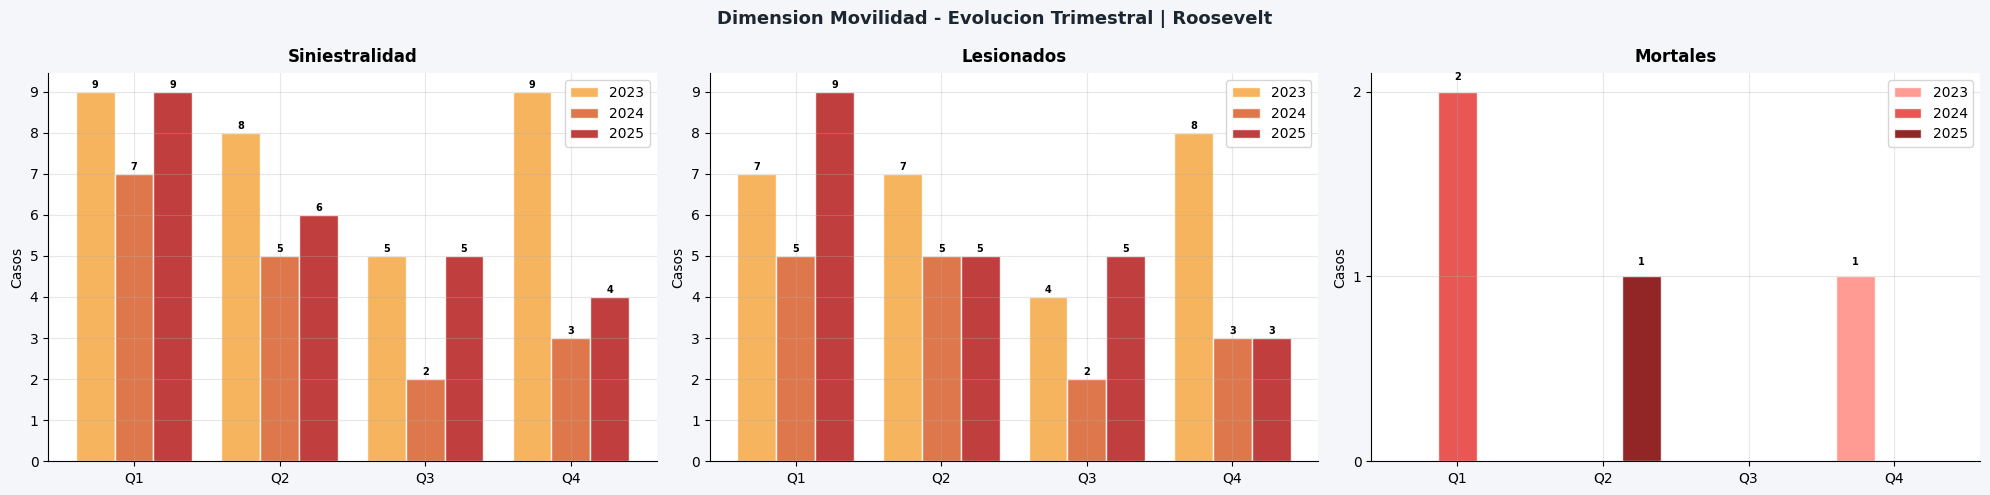

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5), facecolor=BG)
titulo = 'Dimension Movilidad - Evolucion Trimestral | Roosevelt'
fig.suptitle(titulo, fontsize=13, fontweight='bold', color='#1B2631')
CMOV = [['#F5A742','#D95F2B','#B71C1C'],['#F5A742','#D95F2B','#B71C1C'],['#FF8A80','#E53935','#7F0000']]
for pi,(ax,col,tp) in enumerate([(axes[0],'siniestralidad','Siniestralidad'),(axes[1],'lesionados','Lesionados'),(axes[2],'mortales','Mortales')]):
    c = CMOV[pi]
    for idx, año in enumerate(ANIOS):
        vals = corr_trim[corr_trim['año']==año][col].values
        offset = (idx-n/2+0.5)*w
        b = ax.bar(x+offset, vals, w, label=str(año), color=c[idx%3], alpha=0.85, edgecolor='white')
        for bar in b:
            h = bar.get_height()
            if h>0: ax.text(bar.get_x()+bar.get_width()/2, h+0.05, str(int(h)), ha='center', va='bottom', fontsize=7, fontweight='bold')
    ax.set_title(tp, fontweight='bold', pad=8)
    ax.set_xticks(x); ax.set_xticklabels(['Q1','Q2','Q3','Q4'])
    ax.set_ylabel('Casos'); ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True)); ax.legend()
plt.tight_layout()
plt.savefig('itt_roosevelt_mov_trim.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


## Celda 14 Evolucion trimestral: Cohesion Social


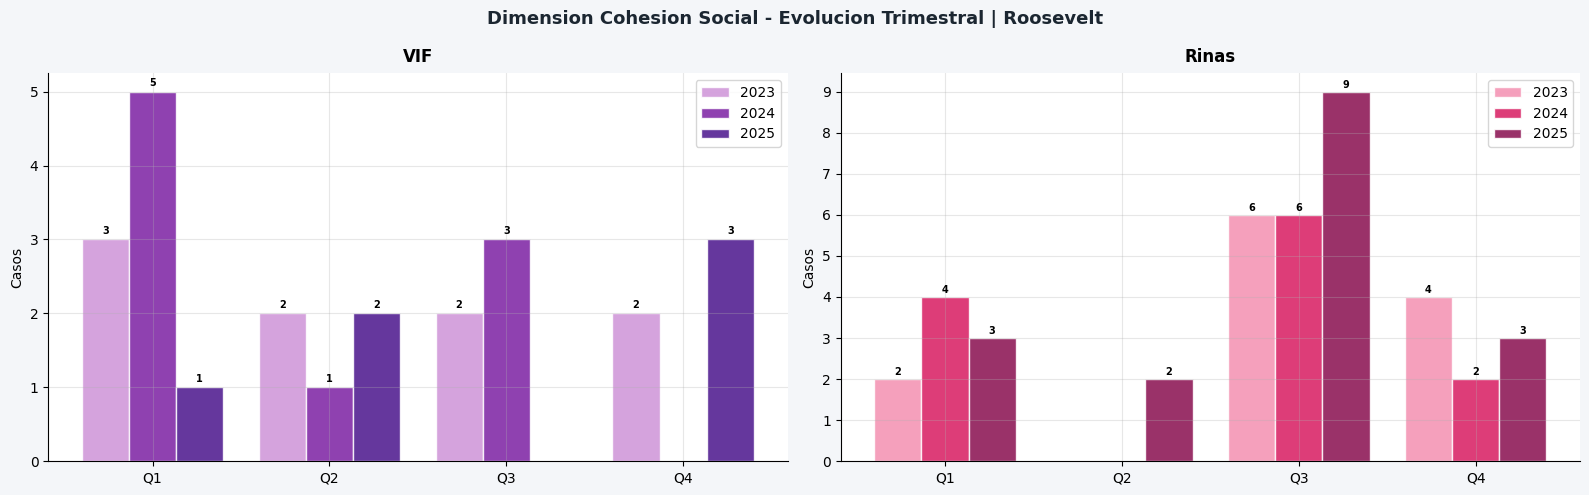

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5), facecolor=BG)
titulo = 'Dimension Cohesion Social - Evolucion Trimestral | Roosevelt'
fig.suptitle(titulo, fontsize=13, fontweight='bold', color='#1B2631')
CVIF = ['#CE93D8','#7B1FA2','#4A148C']; CRIN = ['#F48FB1','#D81B60','#880E4F']
for ax, col, colores, tp in [(axes[0],'vif',CVIF,'VIF'),(axes[1],'rinas',CRIN,'Rinas')]:
    for idx, año in enumerate(ANIOS):
        vals = corr_trim[corr_trim['año']==año][col].values
        offset = (idx-n/2+0.5)*w
        b = ax.bar(x+offset, vals, w, label=str(año), color=colores[idx%3], alpha=0.85, edgecolor='white')
        for bar in b:
            h = bar.get_height()
            if h>0: ax.text(bar.get_x()+bar.get_width()/2, h+0.05, str(int(h)), ha='center', va='bottom', fontsize=7, fontweight='bold')
    ax.set_title(tp, fontweight='bold', pad=8)
    ax.set_xticks(x); ax.set_xticklabels(['Q1','Q2','Q3','Q4'])
    ax.set_ylabel('Casos'); ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True)); ax.legend()
plt.tight_layout()
plt.savefig('itt_roosevelt_coh_trim.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

## Celda 15 ITT Global y composicion por dimension


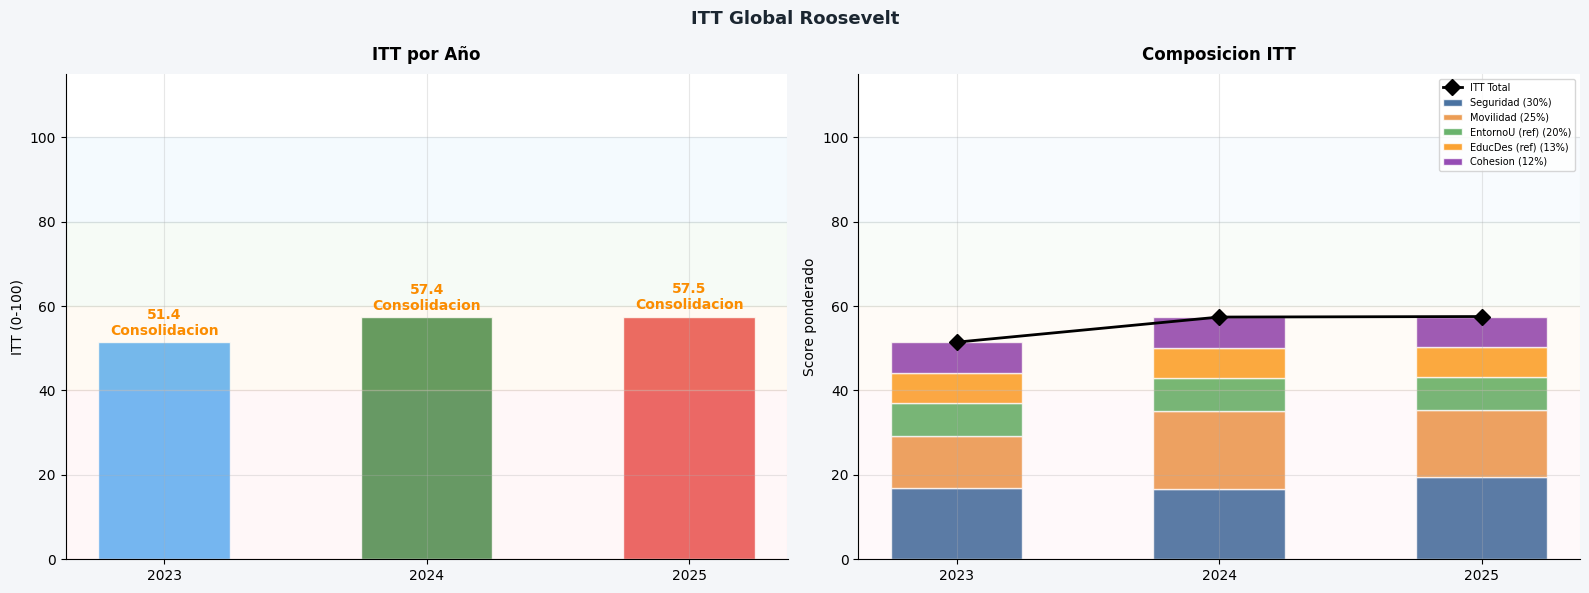

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), facecolor=BG)
fig.suptitle('ITT Global Roosevelt', fontsize=13, fontweight='bold', color='#1B2631')
COLORES_ITT = ['#42A5F5','#2E7D32','#E53935']
band_configs = [(0,40,'#FFCDD2','Emergencia'),(40,60,'#FFE0B2','Consolidacion'),
                (60,80,'#C8E6C9','Avance'),(80,100,'#BBDEFB','Transformacion')]

ax1 = axes[0]
bars = ax1.bar(ANIOS, base['ITT'], color=COLORES_ITT, alpha=0.85, edgecolor='white', width=0.5)
for bar, val, nivel in zip(bars, base['ITT'], base['nivel']):
    ax1.text(bar.get_x()+bar.get_width()/2, val+1, f'{val:.1f}\n{nivel}', ha='center', va='bottom',
        fontsize=10, fontweight='bold', color=NIVEL_COLORS.get(nivel,'#1B2631'))
for y0,y1,c,l in band_configs: ax1.axhspan(y0,y1, alpha=0.15, color=c)
ax1.set_title('ITT por Año', fontweight='bold', pad=10)
ax1.set_ylim(0,115); ax1.set_ylabel('ITT (0-100)'); ax1.set_xticks(ANIOS)

ax2 = axes[1]
dims = ['score_seguridad','score_movilidad','score_entorno_u','score_educ_des','score_cohesion']
dim_lbl = ['Seguridad','Movilidad','EntornoU (ref)','EducDes (ref)','Cohesion']
dim_p = [PESOS['Seguridad'],PESOS['Movilidad'],PESOS['EntornoU'],PESOS['EducDes'],PESOS['Cohesion']]
dim_c = [C_SEG, C_MOV, '#43A047', '#FB8C00', C_COH]
bottom = np.zeros(len(ANIOS))
for dim, lbl, peso, col in zip(dims, dim_lbl, dim_p, dim_c):
    vals = base[dim].values * peso
    ax2.bar(ANIOS, vals, bottom=bottom, label=f'{lbl} ({peso:.0%})', color=col, alpha=0.8, edgecolor='white', width=0.5)
    bottom += vals
ax2.plot(ANIOS, base['ITT'], 'D-', color='black', linewidth=2, markersize=8, label='ITT Total', zorder=5)
for y0,y1,c,l in band_configs: ax2.axhspan(y0,y1, alpha=0.1, color=c)
ax2.set_title('Composicion ITT', fontweight='bold', pad=10)
ax2.set_ylim(0,115); ax2.set_ylabel('Score ponderado'); ax2.set_xticks(ANIOS)
ax2.legend(loc='upper right', fontsize=7)
plt.tight_layout()
plt.savefig('itt_roosevelt_global.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


## Celda 16 Radar ITT: 5 dimensiones


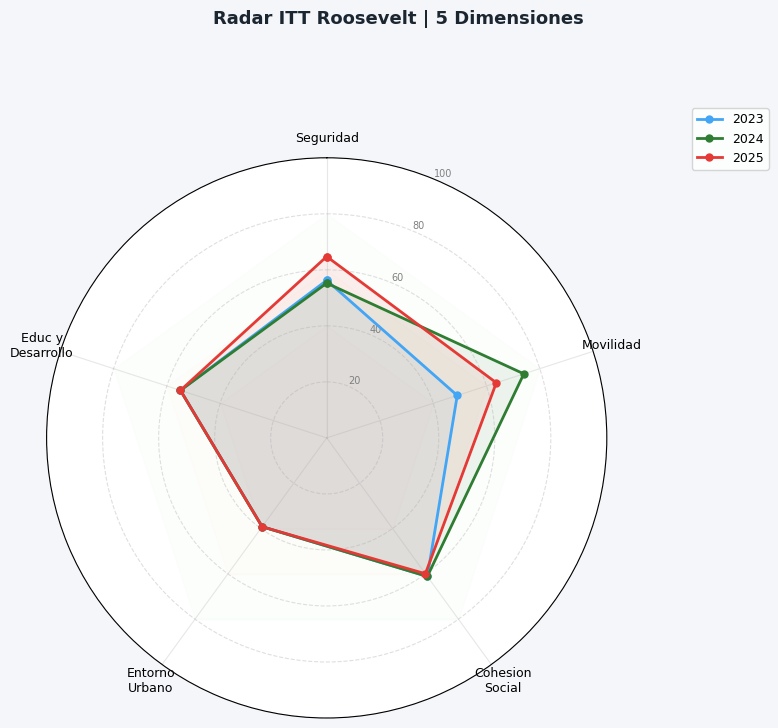

In [26]:
DIMS_LBL = ['Seguridad','Movilidad','Cohesion\nSocial','Entorno\nUrbano','Educ y\nDesarrollo']
N_DIMS = 5
angles = [i/N_DIMS*2*np.pi for i in range(N_DIMS)] + [0]
COLORES_R = ['#42A5F5','#2E7D32','#E53935']

fig, ax = plt.subplots(figsize=(8,8), subplot_kw=dict(polar=True), facecolor=BG)
fig.suptitle('Radar ITT Roosevelt | 5 Dimensiones', fontsize=13, fontweight='bold', color='#1B2631')
ax.set_theta_offset(np.pi/2); ax.set_theta_direction(-1)
ax.set_xticks(angles[:-1]); ax.set_xticklabels(DIMS_LBL, fontsize=9)
ax.set_ylim(0,100); ax.set_yticks([20,40,60,80,100])
ax.set_yticklabels(['20','40','60','80','100'], fontsize=7, color='gray')
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
for y,c in [(40,'#FFCDD2'),(60,'#FFE0B2'),(80,'#C8E6C9')]: ax.fill_between(angles,0,y, alpha=0.04, color=c)

for idx, año in enumerate(ANIOS):
    row = base[base['año']==año].iloc[0]
    vals = [row['score_seguridad'],row['score_movilidad'],row['score_cohesion'],row['score_entorno_u'],row['score_educ_des']]
    vals_c = vals + [vals[0]]
    ax.plot(angles, vals_c, 'o-', color=COLORES_R[idx], linewidth=2, markersize=5, label=str(año))
    ax.fill(angles, vals_c, alpha=0.08, color=COLORES_R[idx])
ax.legend(loc='upper right', bbox_to_anchor=(1.3,1.1), fontsize=9)
plt.tight_layout()
plt.savefig('itt_roosevelt_radar.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

## Celda 17 Exportar a Excel


In [27]:
EXPORT_PATH = 'ITT_Roosevelt.xlsx'
with pd.ExcelWriter(EXPORT_PATH, engine='openpyxl') as writer:
    base.round(2).to_excel(writer, sheet_name='ITT_Anual', index=False)
    corr_trim.to_excel(writer, sheet_name='Series_Trimestrales', index=False)

    # Datos de apoyo
    est = pd.DataFrame({'Elemento':['VBG 2025','Sedes Educativas'],
        'Cantidad':[len(raw_vbg['features']),len(raw_sed['features'])]})
    est.to_excel(writer, sheet_name='Datos_Apoyo', index=False)

    # Umbrales
    refs_df = pd.DataFrame([
        {'Indicador':ind,'ref_min':rmin,'ref_max':rmax,'Inverso':inv,'Descripcion':desc}
        for ind,(rmin,rmax,inv,desc) in REFS.items()
    ])
    refs_df.to_excel(writer, sheet_name='Umbrales_RefMinMax', index=False)

    # Metodologia
    met = pd.DataFrame({'Elemento':[
        'Indice','Zona','Periodo','Normalizacion',
        'Peso Seguridad','Peso Movilidad','Peso EntornoU','Peso EducDes','Peso Cohesion',
        'Entorno Urbano','Educ y Desarrollo','Vulnerabilidad ref',
        'ITT Global','Nivel 1','Nivel 2','Nivel 3','Nivel 4'],
    'Descripcion':[
        'Indice de Transformacion Territorial',
        'Corredor Roosevelt, Cali',
        f'{ANIOS[0]}-{ANIOS[-1]}',
        'ref_min/ref_max fijos por indicador (juicio experto inicial)',
        f'{PESOS["Seguridad"]:.0%}',f'{PESOS["Movilidad"]:.0%}',
        f'{PESOS["EntornoU"]:.0%} - ref={REF_ENTORNO_U}',
        f'{PESOS["EducDes"]:.0%} - ref={REF_EDUC_DES}',
        f'{PESOS["Cohesion"]:.0%}',
        f'Score fijo={REF_ENTORNO_U} (Pulmon de Oriente)',
        f'Score fijo={REF_EDUC_DES} (Pulmon de Oriente)',
        f'{REF_VULNERABILIDAD} (referente provisional)',
        'ITT = 0.30*Seg + 0.25*Mov + 0.20*EntU + 0.13*EyD + 0.12*Coh',
        '0-40 Emergencia','40-60 Consolidacion','60-80 Avance','80-100 Transformacion']
    })
    met.to_excel(writer, sheet_name='Metodologia', index=False)

print(f'Exportado: {EXPORT_PATH}')
print('Hojas: ITT_Anual | Series_Trimestrales | Datos_Apoyo | Umbrales_RefMinMax | Metodologia')



Exportado: ITT_Roosevelt.xlsx
Hojas: ITT_Anual | Series_Trimestrales | Datos_Apoyo | Umbrales_RefMinMax | Metodologia
